## **BERT MODEL FOR TEXT :**

**Install /Imports :**


In [ ]:
!pip install transformers torch pandas scikit-learn seaborn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Data Loading :**

In [ ]:
df = pd.read_csv("/content/AI_Human.csv",nrows=100000)

print("Original Dataset Shape:", df.shape)

df.head()

Original Dataset Shape: (100000, 2)


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [ ]:
print(df.columns)

Index(['text', 'generated'], dtype='object')


In [ ]:
df = df[['text','generated']]

print("After removing extra column:", df.shape)

After removing extra column: (100000, 2)


**Data Cleaning :**

In [ ]:
df = df.dropna()

print("After removing NaN:", df.shape)

After removing NaN: (100000, 2)


In [ ]:
df['label'] = df['generated'].astype(int)

In [ ]:
print(df['label'].value_counts())

label
0    52916
1    47084
Name: count, dtype: int64


In [ ]:
min_class = df['label'].value_counts().min()

In [ ]:
df_balanced = df.groupby('label').sample(n=min_class, random_state=42)

In [ ]:
df_balanced['label'].value_counts()

,count
label,
0,47084
1,47084


In [ ]:
df = df.dropna()

df['text'] = df['text'].astype(str)

# The 'generated' column already contains 0.0 and 1.0, which can be directly used as labels.
# We can create a 'label' column from 'generated' and convert it to integer type.
df['label'] = df['generated'].astype(int)

In [ ]:
min_class = df['label'].value_counts().min()
df_balanced = df.groupby('label').sample(n=min_class, random_state=42)

df_balanced = df_balanced[['text', 'label']]
df_balanced = df_balanced.sample(n=10000, random_state=42)

print("Final Dataset Shape:", df_balanced.shape)

Final Dataset Shape: (10000, 2)


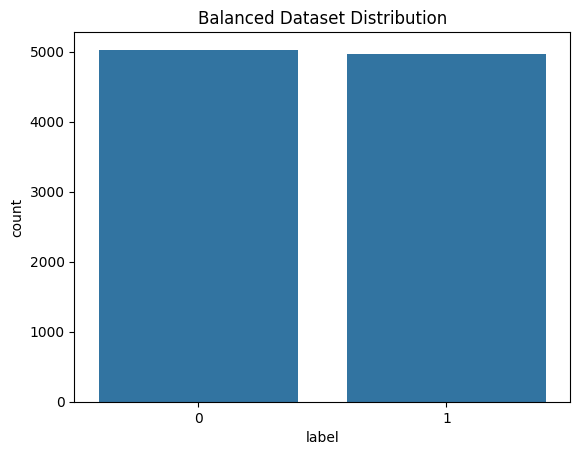

In [ ]:
sns.countplot(x='label', data=df_balanced)

plt.title("Balanced Dataset Distribution")

plt.show()

**Train / Test Split :**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.3,
    random_state=42
)

**Load BERT Tokenizer :**

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**Tokenize Text :**

In [ ]:
def tokenize_in_batches(texts, tokenizer, batch_size=1000):
    encodings = {"input_ids": [], "attention_mask": []}

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        batch_enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=128
        )

        encodings["input_ids"].extend(batch_enc["input_ids"])
        encodings["attention_mask"].extend(batch_enc["attention_mask"])

    return encodings


train_encodings = tokenize_in_batches(X_train, tokenizer)
test_encodings = tokenize_in_batches(X_test, tokenizer)

**Create PyTorch Dataset :**

In [ ]:
class TextDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)


train_dataset = TextDataset(train_encodings, y_train)

test_dataset = TextDataset(test_encodings, y_test)

**Load BERT Model :**

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Training Configuration :**

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',

    num_train_epochs=1,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    warmup_steps=100,

    weight_decay=0.01,

    logging_dir='./logs',

    logging_steps=100,

    eval_strategy="epoch", # Corrected from evaluation_strategy

    save_strategy="epoch"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


**Create Trainer :**

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',

    num_train_epochs=1,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    warmup_steps=50,

    weight_decay=0.01,

    logging_dir='./logs',

    logging_steps=500,

    eval_strategy="epoch",      # Corrected from evaluation_strategy
    save_strategy="epoch",

    dataloader_num_workers=2,

    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.019807,0.036343


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2188, training_loss=0.053101048717986946, metrics={'train_runtime': 490.8589, 'train_samples_per_second': 142.607, 'train_steps_per_second': 4.457, 'total_flos': 4604443468800000.0, 'train_loss': 0.053101048717986946, 'epoch': 1.0})

**Evaluate Model :**

In [ ]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

print("Accuracy:", accuracy_score(y_test, preds))

print(classification_report(y_test, preds))

Accuracy: 0.9906
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     15832
           1       0.98      1.00      0.99     14168

    accuracy                           0.99     30000
   macro avg       0.99      0.99      0.99     30000
weighted avg       0.99      0.99      0.99     30000



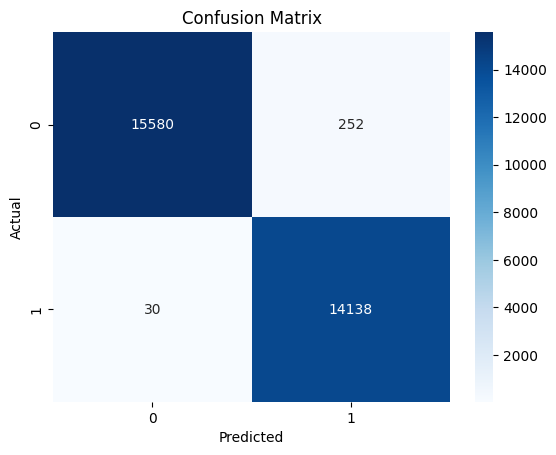

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## **CNN MODEL FOR IMAGE :**

**Imports / Installs :**

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

**File Upload :**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
import zipfile

with zipfile.ZipFile("/content/archive (4).zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'train', '.ipynb_checkpoints', 'results', 'archive (4).zip', 'AI_Human.csv', 'test', 'sample_data']


In [ ]:
train_dir = "/content/train"
test_dir = "/content/test"

In [ ]:
import os

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))

Train classes: ['FAKE', 'REAL']
Test classes: ['FAKE', 'REAL']


 **Data Preprocessing :**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

**Use simpler preprocessing :**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

**Reload generators :**

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


**Build simple CNN :**

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train faster :**

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=3
)

Epoch 1/3
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 27ms/step - accuracy: 0.8846 - loss: 0.2754 - val_accuracy: 0.9191 - val_loss: 0.2053
Epoch 2/3
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 81s 26ms/step - accuracy: 0.9323 - loss: 0.1748 - val_accuracy: 0.9347 - val_loss: 0.1714
Epoch 3/3
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 78s 25ms/step - accuracy: 0.9466 - loss: 0.1380 - val_accuracy: 0.9381 - val_loss: 0.1566


**Evaluate on test set :**

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9381 - loss: 0.1566
Test Loss: 0.15658140182495117
Test Accuracy: 0.9380999803543091


**Predict labels :**

In [ ]:
import numpy as np

pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step


**Classification report :**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, pred_labels, target_names=['FAKE', 'REAL']))

              precision    recall  f1-score   support

        FAKE       0.93      0.95      0.94     10000
        REAL       0.95      0.93      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



**Confusion matrix :**

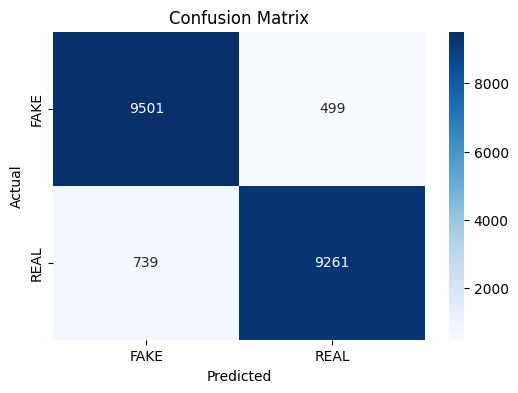

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Testing :**

Image path: /content/test/FAKE/341 (3).jpg
Actual label: FAKE
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step
Predicted label: FAKE
Confidence score: 0.00022261284


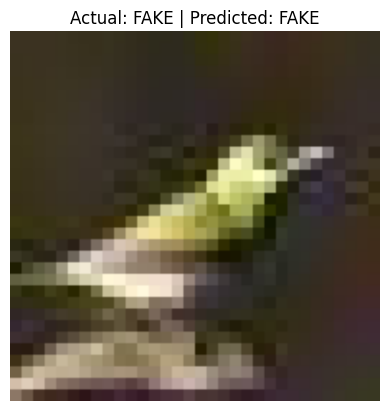

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Paths
real_path = "/content/test/REAL"
fake_path = "/content/test/FAKE"

# Randomly choose class
chosen_class = random.choice(["REAL", "FAKE"])

if chosen_class == "REAL":
    img_path = os.path.join(real_path, random.choice(os.listdir(real_path)))
    true_label = "REAL"
else:
    img_path = os.path.join(fake_path, random.choice(os.listdir(fake_path)))
    true_label = "FAKE"

print("Image path:", img_path)
print("Actual label:", true_label)

# Load image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)

# Preprocess
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

pred_prob = prediction[0][0]

if pred_prob > 0.5:
    predicted_label = "REAL"
else:
    predicted_label = "FAKE"

# Show results
print("Predicted label:", predicted_label)
print("Confidence score:", pred_prob)

# Display image
plt.imshow(img)
plt.title(f"Actual: {true_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()

## **CNN + MFCC EXTRACTION FOR AUDIO :**

**File Upload :**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving AudioDataset.zip to AudioDataset.zip


In [2]:
import zipfile
import os

with zipfile.ZipFile("/content/AudioDataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/audio_data")

In [3]:
print(os.listdir("/content"))

['.config', 'audio_data', '.ipynb_checkpoints', 'AudioDataset.zip', 'sample_data']


In [4]:
print(os.listdir("/content/audio_data"))

['AudioDataset']


In [5]:
real_path = "/content/audio_data/AudioDataset/REAL"
fake_path = "/content/audio_data/AudioDataset/FAKE"

In [6]:
!pip install librosa soundfile

**Import libraries :**

In [7]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models

**Audio preprocessing function :**

In [8]:
def extract_features(file_path, max_pad_len=174):
    try:
        audio, sr = librosa.load(file_path, sr=None, duration=3)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc

    except Exception as e:
        print(f"Error in {file_path}: {e}")
        return None

**Load REAL and FAKE .wav files**

In [9]:
X = []
y = []
file_paths = []

In [10]:
for file_name in os.listdir(real_path):
    file_path = os.path.join(real_path, file_name)

    if file_name.lower().endswith(".wav"):
        features = extract_features(file_path)

        if features is not None:
            X.append(features)
            y.append(1)   # REAL
            file_paths.append(file_path)

In [11]:
for file_name in os.listdir(fake_path):
    file_path = os.path.join(fake_path, file_name)

    if file_name.lower().endswith(".wav"):
        features = extract_features(file_path)

        if features is not None:
            X.append(features)
            y.append(0)   # FAKE
            file_paths.append(file_path)

**collect file paths :**

In [12]:
import os
import random

real_files = [
    os.path.join(real_path, f)
    for f in os.listdir(real_path)
    if f.lower().endswith(".wav")
]

fake_files = [
    os.path.join(fake_path, f)
    for f in os.listdir(fake_path)
    if f.lower().endswith(".wav")
]

print("REAL files:", len(real_files))
print("FAKE files:", len(fake_files))

REAL files: 335
FAKE files: 271


**balance classes :**

In [13]:
random.seed(42)

min_count = min(len(real_files), len(fake_files))

real_files = random.sample(real_files, min_count)
fake_files = random.sample(fake_files, min_count)

print("Balanced REAL:", len(real_files))
print("Balanced FAKE:", len(fake_files))

Balanced REAL: 271
Balanced FAKE: 271


**split file paths first :**

In [14]:
from sklearn.model_selection import train_test_split

real_train, real_test = train_test_split(real_files, test_size=0.2, random_state=42)
fake_train, fake_test = train_test_split(fake_files, test_size=0.2, random_state=42)

print("REAL train:", len(real_train), "REAL test:", len(real_test))
print("FAKE train:", len(fake_train), "FAKE test:", len(fake_test))

REAL train: 216 REAL test: 55
FAKE train: 216 FAKE test: 55


**MFCC extraction function :**

In [30]:
import librosa
import numpy as np

def extract_features(file_path, max_pad_len=120):
    try:
        audio, sr = librosa.load(file_path, sr=None, duration=2)

        # Add noise
        audio = audio + 0.01 * np.random.randn(len(audio))

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)

        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc

    except Exception as e:
        print(f"Error in {file_path}: {e}")
        return None

**build train and test separately :**

In [31]:
X_train, y_train, paths_train = [], [], []
X_test, y_test, paths_test = [], [], []

**REAL train :**

In [32]:
for file_path in real_train:
    features = extract_features(file_path)
    if features is not None:
        X_train.append(features)
        y_train.append(1)
        paths_train.append(file_path)

**FAKE train :**

In [33]:
for file_path in fake_train:
    features = extract_features(file_path)
    if features is not None:
        X_train.append(features)
        y_train.append(0)
        paths_train.append(file_path)

**REAL test :**

In [34]:
for file_path in real_test:
    features = extract_features(file_path)
    if features is not None:
        X_test.append(features)
        y_test.append(1)
        paths_test.append(file_path)

**FAKE test :**

In [35]:
for file_path in fake_test:
    features = extract_features(file_path)
    if features is not None:
        X_test.append(features)
        y_test.append(0)
        paths_test.append(file_path)

**convert to arrays :**

In [36]:
X_train = np.array(X_train)[..., np.newaxis]
X_test = np.array(X_test)[..., np.newaxis]

y_train = np.array(y_train)
y_test = np.array(y_test)

paths_train = np.array(paths_train)
paths_test = np.array(paths_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (432, 20, 120, 1)
X_test: (110, 20, 120, 1)
y_train: (432,)
y_test: (110,)


**Build a slightly safer CNN :**

In [37]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(20,120,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile model :**

In [38]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Add early stopping :**

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**Train with fewer epochs :**

In [40]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=2,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 482ms/step - accuracy: 0.5579 - loss: 2.9373 - val_accuracy: 0.8000 - val_loss: 0.3605
Epoch 2/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7130 - loss: 0.5815 - val_accuracy: 0.9182 - val_loss: 0.2889


**Evaluate :**

In [41]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9182 - loss: 0.2889
Test Loss: 0.2888716757297516
Test Accuracy: 0.918181836605072


**Classification report :**

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=["FAKE", "REAL"]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step
              precision    recall  f1-score   support

        FAKE       0.90      0.95      0.92        55
        REAL       0.94      0.89      0.92        55

    accuracy                           0.92       110
   macro avg       0.92      0.92      0.92       110
weighted avg       0.92      0.92      0.92       110



**Confusion matrix :**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[43 12]
 [13 42]]


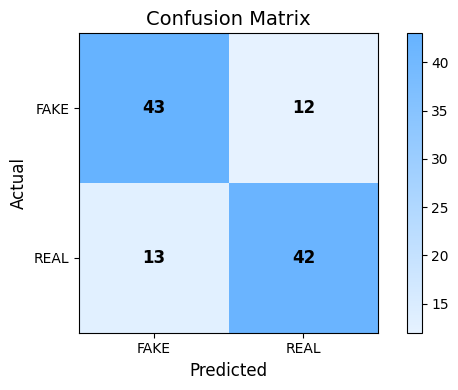

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Example: if cm not defined (remove if already defined)
# cm = np.array([[50, 5],
#                [3, 60]])

#  Custom light blue colormap
light_blue = LinearSegmentedColormap.from_list(
    "light_blue",
    ["#e6f2ff", "#66b3ff"]  # very light → medium blue
)

plt.figure(figsize=(6, 4))

#  Apply custom colormap
plt.imshow(cm, cmap=light_blue)

# Title
plt.title("Confusion Matrix", fontsize=14)

# Colorbar
plt.colorbar()

# Axis labels
plt.xticks([0, 1], ["FAKE", "REAL"])
plt.yticks([0, 1], ["FAKE", "REAL"])
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

#  Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            cm[i, j],
            ha='center',
            va='center',
            color='black',
            fontsize=12,
            fontweight='bold'
        )

# Layout fix
plt.tight_layout()

# Show plot
plt.show()